In [1]:
import pandas as pd

df = pd.read_csv("data.csv")

print(df.head())
print(df.shape)
print(df.info())

                         flrID          beginTime           peakTime  \
0  2015-01-03T09:43:00-FLR-001  2015-01-03T09:43Z  2015-01-03T09:47Z   
1  2015-01-04T15:18:00-FLR-001  2015-01-04T15:18Z  2015-01-04T15:36Z   
2  2015-01-13T04:13:00-FLR-001  2015-01-13T04:13Z  2015-01-13T04:24Z   
3  2015-01-13T04:45:00-FLR-001  2015-01-13T04:45Z  2015-01-13T04:58Z   
4  2015-01-14T12:48:00-FLR-001  2015-01-14T12:48Z  2015-01-14T12:57Z   

             endTime classType sourceLocation  activeRegionNum  linkedEvents  
0  2015-01-03T09:50Z      M1.1         S05E15          12253.0             0  
1  2015-01-04T15:53Z      M1.3         S05E01          12253.0             0  
2  2015-01-13T04:38Z      M5.6         N07W69          12257.0             1  
3  2015-01-13T05:10Z      M4.9         N07W71          12257.0             0  
4  2015-01-14T13:08Z      M2.2         N07W90          12257.0             0  
(2740, 8)
<class 'pandas.DataFrame'>
RangeIndex: 2740 entries, 0 to 2739
Data columns (total 

In [2]:
df["beginTime"] = pd.to_datetime(df["beginTime"])
df["peakTime"] = pd.to_datetime(df["peakTime"])
df["endTime"] = pd.to_datetime(df["endTime"])

# Duration of flare in minutes
df["duration_minutes"] = (
    (df["endTime"] - df["beginTime"]).dt.total_seconds() / 60
)

# Time to reach peak
df["rise_time_minutes"] = (
    (df["peakTime"] - df["beginTime"]).dt.total_seconds() / 60
)

# Extract date features
df["month"] = df["beginTime"].dt.month
df["hour"] = df["beginTime"].dt.hour

print(df.head())

                         flrID                 beginTime  \
0  2015-01-03T09:43:00-FLR-001 2015-01-03 09:43:00+00:00   
1  2015-01-04T15:18:00-FLR-001 2015-01-04 15:18:00+00:00   
2  2015-01-13T04:13:00-FLR-001 2015-01-13 04:13:00+00:00   
3  2015-01-13T04:45:00-FLR-001 2015-01-13 04:45:00+00:00   
4  2015-01-14T12:48:00-FLR-001 2015-01-14 12:48:00+00:00   

                   peakTime                   endTime classType  \
0 2015-01-03 09:47:00+00:00 2015-01-03 09:50:00+00:00      M1.1   
1 2015-01-04 15:36:00+00:00 2015-01-04 15:53:00+00:00      M1.3   
2 2015-01-13 04:24:00+00:00 2015-01-13 04:38:00+00:00      M5.6   
3 2015-01-13 04:58:00+00:00 2015-01-13 05:10:00+00:00      M4.9   
4 2015-01-14 12:57:00+00:00 2015-01-14 13:08:00+00:00      M2.2   

  sourceLocation  activeRegionNum  linkedEvents  duration_minutes  \
0         S05E15          12253.0             0               7.0   
1         S05E01          12253.0             0              35.0   
2         N07W69          122

In [3]:
df["activeRegionNum"] = df["activeRegionNum"].fillna(
    df["activeRegionNum"].median()
)

df["duration_minutes"] = df["duration_minutes"].fillna(
    df["duration_minutes"].median()
)

In [4]:
features = [
    "activeRegionNum",
    "linkedEvents",
    "duration_minutes",
    "rise_time_minutes",
    "month",
    "hour"
]

X = df[features]

y = df["classType"]

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print(le.classes_)

['A9.1' 'B1.2' 'B1.3' 'B1.4' 'B1.6' 'B1.9' 'B2.2' 'B2.4' 'B2.5' 'B2.6'
 'B2.9' 'B3.1' 'B3.3' 'B3.7' 'B3.8' 'B4.5' 'B4.8' 'B4.9' 'B5.3' 'B5.4'
 'B5.7' 'B5.8' 'B5.9' 'B6.0' 'B6.1' 'B6.9' 'B7.0' 'B7.1' 'B7.2' 'B7.5'
 'B7.6' 'B7.9' 'B8.4' 'B8.5' 'B8.8' 'B9.5' 'B9.7' 'B9.8' 'C1.0' 'C1.1'
 'C1.2' 'C1.3' 'C1.4' 'C1.5' 'C1.6' 'C1.7' 'C1.8' 'C1.9' 'C2.0' 'C2.1'
 'C2.2' 'C2.3' 'C2.4' 'C2.5' 'C2.6' 'C2.7' 'C2.8' 'C2.9' 'C3.0' 'C3.1'
 'C3.2' 'C3.3' 'C3.4' 'C3.5' 'C3.6' 'C3.7' 'C3.8' 'C3.9' 'C4.0' 'C4.1'
 'C4.2' 'C4.3' 'C4.4' 'C4.5' 'C4.6' 'C4.7' 'C4.8' 'C4.9' 'C5.0' 'C5.1'
 'C5.2' 'C5.3' 'C5.4' 'C5.5' 'C5.6' 'C5.7' 'C5.8' 'C5.9' 'C6.0' 'C6.1'
 'C6.2' 'C6.3' 'C6.4' 'C6.5' 'C6.6' 'C6.7' 'C6.8' 'C7.0' 'C7.1' 'C7.2'
 'C7.3' 'C7.4' 'C7.5' 'C7.6' 'C7.7' 'C7.8' 'C7.9' 'C8.0' 'C8.1' 'C8.2'
 'C8.3' 'C8.4' 'C8.5' 'C8.6' 'C8.7' 'C8.8' 'C8.9' 'C9.0' 'C9.1' 'C9.2'
 'C9.3' 'C9.4' 'C9.5' 'C9.6' 'C9.7' 'C9.8' 'C9.9' 'M1.0' 'M1.1' 'M1.2'
 'M1.3' 'M1.4' 'M1.5' 'M1.6' 'M1.7' 'M1.8' 'M1.9' 'M2.0' 'M2.1' 'M2.2'
 'M2.3

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    
)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.051094890510948905


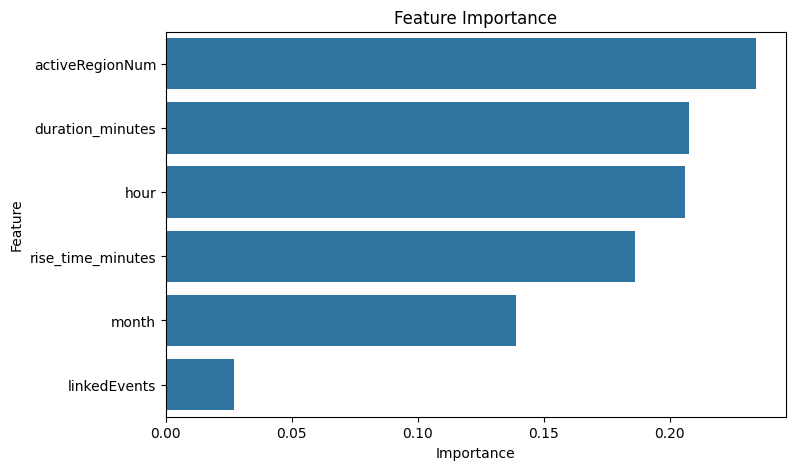

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance")
plt.show()

In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

n_features = X_train_scaled.shape[1]

n_classes = len(le.classes_)

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(n_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=32
)


Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.0643 - loss: 5.0572 - val_accuracy: 0.0766 - val_loss: 5.2001
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0862 - loss: 4.2868 - val_accuracy: 0.0766 - val_loss: 4.8657
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0890 - loss: 4.1387 - val_accuracy: 0.0693 - val_loss: 4.6724
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0953 - loss: 4.0863 - val_accuracy: 0.0803 - val_loss: 4.5498
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0935 - loss: 4.0490 - val_accuracy: 0.0657 - val_loss: 4.4763
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0931 - loss: 4.0151 - val_accuracy: 0.0785 - val_loss: 4.4445
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1022 - loss: 3.9622 - val_accuracy: 0.0693 - val_loss: 4.4452
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1086 - loss: 3.9345 - val_accuracy: 0.0785 - val_loss

In [16]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

y_pred = mlp.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("MLP Accuracy:", accuracy)

MLP Accuracy: 0.07116788321167883


c:\Users\kaliv\OneDrive\Desktop\ML Workshop\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [17]:
from sklearn.metrics import accuracy_score

y_pred = mlp.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("MLP Accuracy:", accuracy)

MLP Accuracy: 0.07116788321167883


In [20]:
import pickle

with open("solar_flare_rf.pkl", "wb") as f:
    pickle.dump(rf, f)

with open("solar_flare_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("solar_flare_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

model.save("solar_flare_nn.keras")